# Import Depedencies

In [4]:
import os
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, learning_curve
from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

# Load Data

In [5]:
filename = 'house_price.csv'

def check_data(name_file):
    for dirname, _, filenames in os.walk('../../00-datasets'):
        if name_file in filenames:
            return os.path.join(dirname, name_file)

df = pd.read_csv(check_data(filename))
df.head()

,area,rooms,price
0,2104,3,399900
1,1600,3,329900
2,2400,3,369000
3,1416,2,232000
4,3000,4,539900


# Exploratory Data Analysis

## Univariate Analysis

In [6]:
# Check Row and Column
print('Shape of data:', df.shape, '\n')

# Check Types of Data
print(df.dtypes, '\n')

# Check Missing Value
print(df.isnull().sum(), '\n')

# Check Duplicate
print(df.duplicated().sum())

# Check Value less Than Zero
print(df[(df['area'] < 0) | (df['price'] < 0)].sum())

Shape of data: (47, 3) 

area     int64
rooms    int64
price    int64
dtype: object 

area     0
rooms    0
price    0
dtype: int64 

0
area     0
rooms    0
price    0
dtype: int64


            area      rooms      price
count  47.000000  47.000000  47.000000
mean    7.533818   3.170213  12.678416
std     0.365886   0.760982   0.341929
min     6.748760   1.000000  12.042971
25%     7.267519   3.000000  12.428820
50%     7.543803   3.000000  12.611208
75%     7.727442   4.000000  12.858763
max     8.407155   5.000000  13.458694


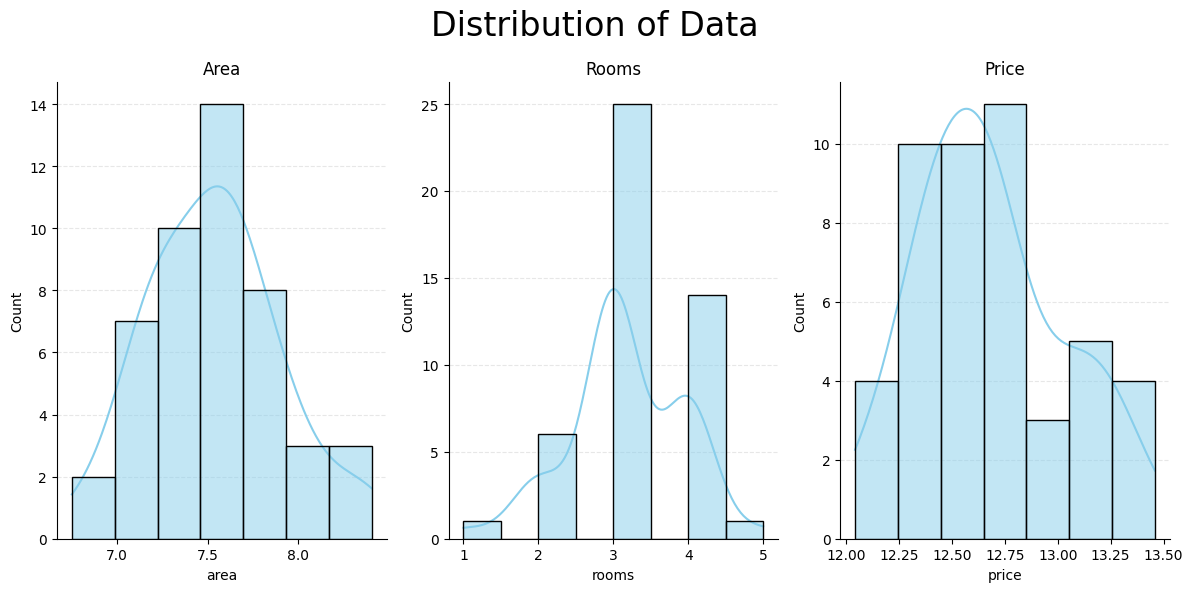

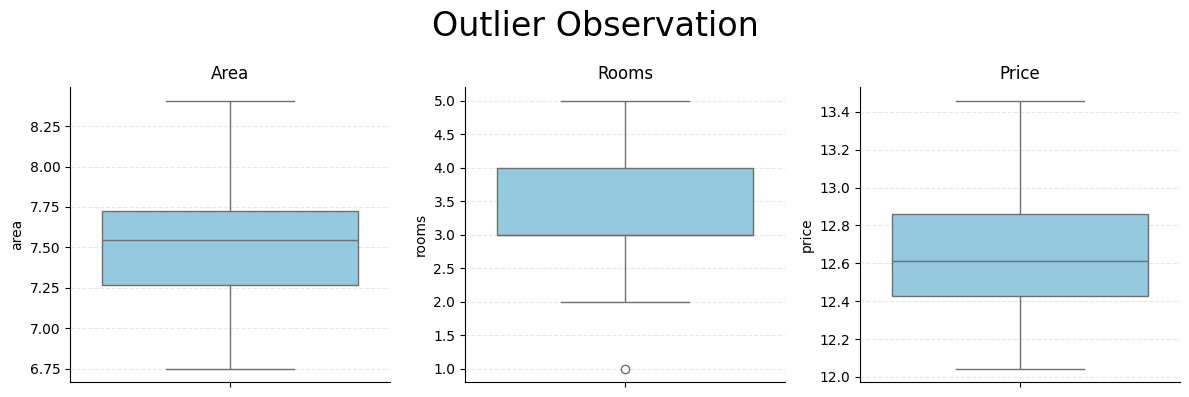

In [22]:
# Check Data Distribution
print(df.describe())

def distribution(data):
    _, ax = plt.subplots(1, len(data.columns), figsize=(12, 6))
    plt.suptitle('Distribution of Data', fontsize=24, fontweight="550", y=0.98)
    for i, col in enumerate(data.columns):
        sns.histplot(data=data, x=col, kde=True, ax=ax[i], color='skyblue', zorder=3)
        ax[i].grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
        ax[i].spines[['top', 'right']].set_visible(False)
        ax[i].set_title(col.title())
    plt.tight_layout()
    plt.show()

distribution(df)

# Check Outlier
def outlier(data):
    _, ax = plt.subplots(1, len(data.columns), figsize=(12, 4))
    plt.suptitle('Outlier Observation', fontsize=24, fontweight="550", y=0.98)
    for i, col in enumerate(data.columns):
        sns.boxplot(data=data, y=col, ax=ax[i], color='skyblue', zorder=3)
        ax[i].grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
        ax[i].spines[['top', 'right']].set_visible(False)
        ax[i].set_title(col.title())
    plt.tight_layout()
    plt.show()

outlier(df)

## Bivariate Analysis

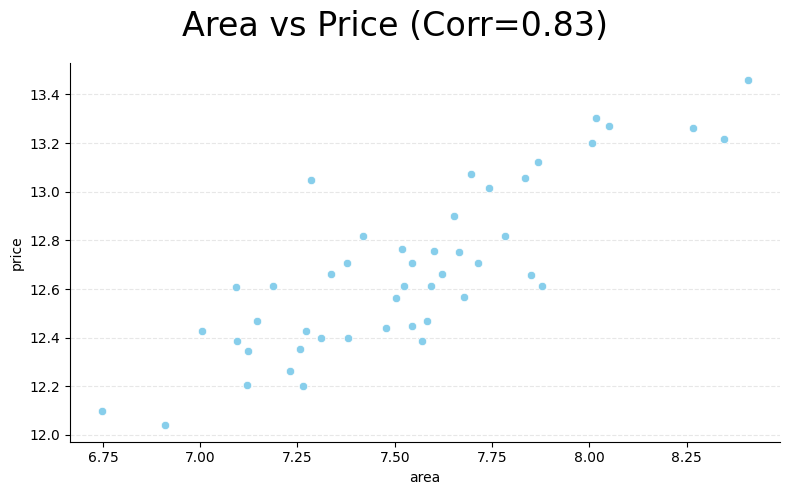

In [23]:
def scatterplot(data, x, y):
    corr = df['area'].corr(df['price'])

    _, ax = plt.subplots(figsize=(8, 5))
    plt.suptitle(f'{x.title()} vs {y.title()} (Corr={corr:.2f})', fontsize=24, fontweight="550", y=0.98)
    sns.scatterplot(data=df, x=x, y=y, color='skyblue', zorder=3)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
    plt.tight_layout()
    plt.show()

scatterplot(df, 'area', 'price')

## Multivariate Analysis

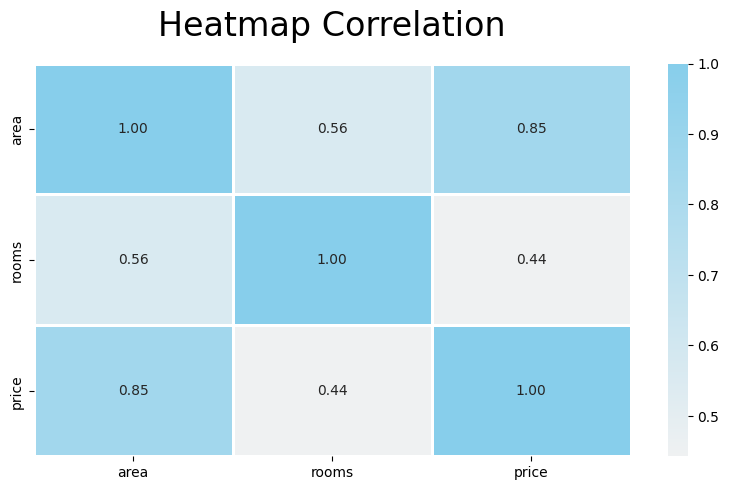

In [9]:
def correlation(data):
    plt.figure(figsize=(8, 5))
    plt.title('Heatmap Correlation', fontsize=24, fontweight="550", y=1.05)
    sns.heatmap(data.corr(), annot=True, fmt='.2f', linewidth=1, cmap=sns.light_palette('skyblue', as_cmap=True))
    plt.tight_layout()
    plt.show()

correlation(df)

# Feature Engineering

## Feature Transformation

In [10]:
df['area'] = np.log1p(df['area'])
df['price'] = np.log1p(df['price'])

## Feature Selection

In [11]:
# Feature
X = df[['area']]

# Target
y = df['price']

# Model Training

In [12]:
# Split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [13]:
# Fitting Model
regressor = LinearRegression()
regressor.fit(X_train, y_train)

# Predict Target
y_pred = regressor.predict(X_test)

# Model Evaluation

## Model Performance Metrics

In [14]:
print('MAE:', mean_absolute_error(y_test, y_pred))
print('RSME:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('R2:', r2_score(y_test, y_pred))

MAE: 0.19301571474861792
RSME: 0.2082480365264958
R2: 0.7056310534135042


## Cross Validation

In [25]:
scores = cross_val_score(
    LinearRegression(),
    X, y,
    cv=5,
    scoring='r2'
)

print('Cross Validation with R2 Score:')
print(scores)
print(scores.mean())

Cross Validation with R2 Score:
[0.72652549 0.75585779 0.39449725 0.76449916 0.48260026]
0.6247959896051912


## Regression Coefficients

In [16]:
print('Intercept:', regressor.intercept_)
print('Slope:', regressor.coef_[0])

Intercept: 7.243649510575333
Slope: 0.7210701905537551


## Visualization Regression Train & Test

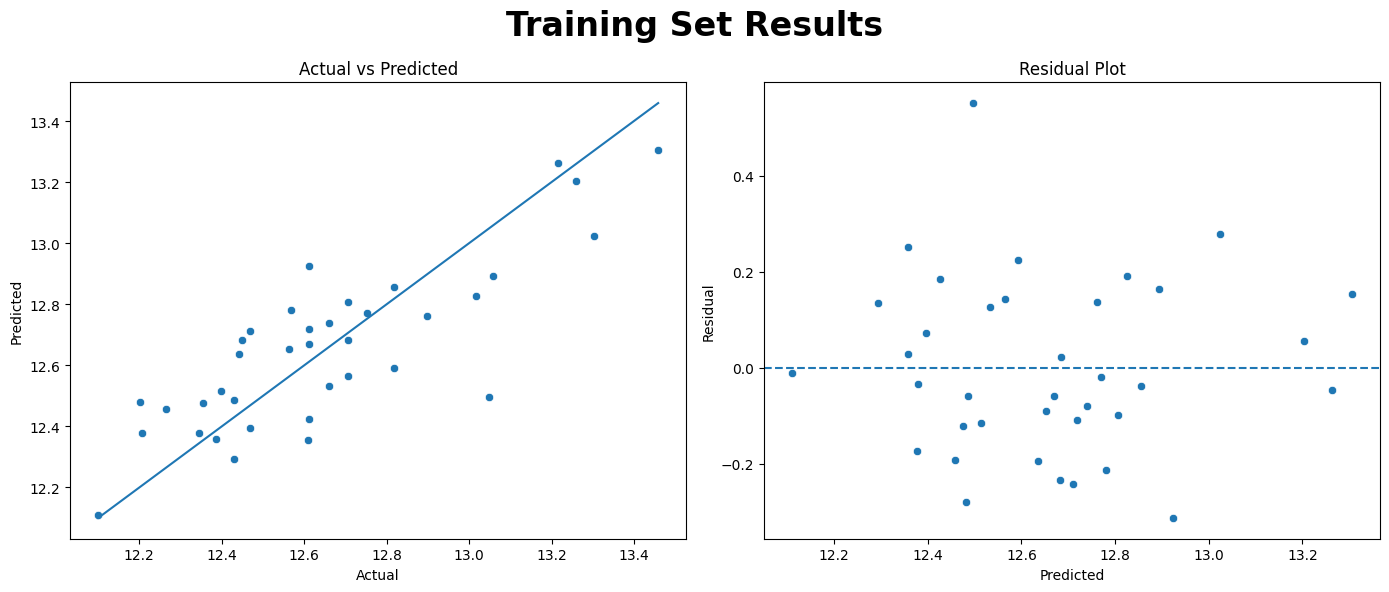

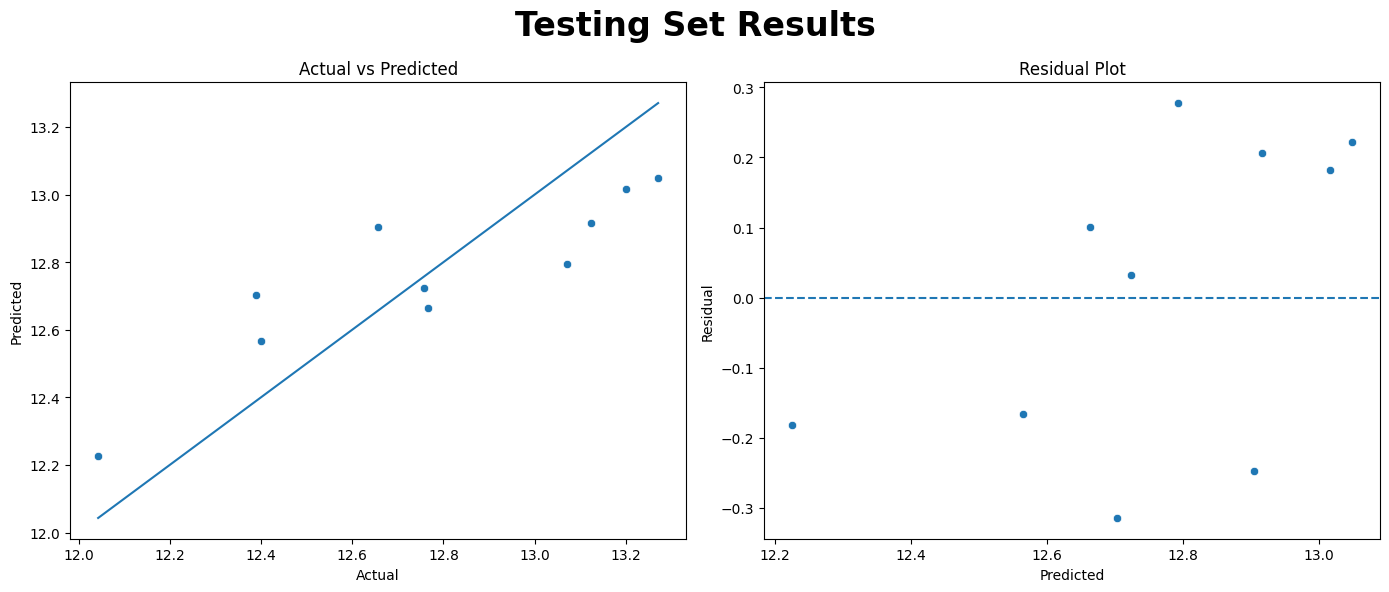

In [17]:
def visualization(title, x, y):

    y_pred = regressor.predict(x)

    _, ax = plt.subplots(1, 2, figsize=(14, 6))

    plt.suptitle(
        title.title(),
        fontsize=24,
        fontweight='bold'
    )

    # Actual vs Predicted
    sns.scatterplot(
        x=y,
        y=y_pred,
        ax=ax[0]
    )

    ax[0].set_title('Actual vs Predicted')
    ax[0].set_xlabel('Actual')
    ax[0].set_ylabel('Predicted')

    min_val = min(y.min(), y_pred.min())
    max_val = max(y.max(), y_pred.max())

    ax[0].plot(
        [min_val, max_val],
        [min_val, max_val]
    )

    # Residual Plot
    residual = y - y_pred

    sns.scatterplot(
        x=y_pred,
        y=residual,
        ax=ax[1]
    )

    ax[1].axhline(
        y=0,
        linestyle='--'
    )

    ax[1].set_title('Residual Plot')
    ax[1].set_xlabel('Predicted')
    ax[1].set_ylabel('Residual')

    plt.tight_layout()
    plt.show()

visualization('Training set results', X_train, y_train)
visualization('Testing set results', X_test, y_test)

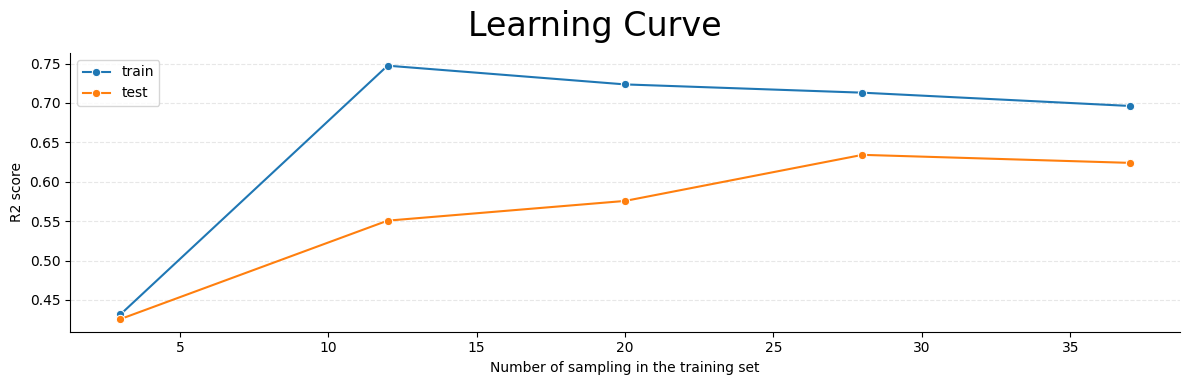

None


In [31]:
def learn_curve(model, feature, target):
    train_size, train_scores, test_scores = learning_curve(
        estimator=model,
        X=feature,
        y=target,
        cv=5,
        scoring='r2',
        n_jobs=-1
    )
    _, ax = plt.subplots(1, 1, figsize=(12, 4))
    plt.suptitle('Learning Curve', fontsize=24, fontweight="550", y=0.95)

    sns.lineplot(
        x=train_size,
        y=train_scores.mean(axis=1),
        marker='o',
        label='train',
        zorder=3
    )

    sns.lineplot(
        x=train_size,
        y=test_scores.mean(axis=1),
        marker='o',
        label='test',
        zorder=3
    )

    ax.grid(axis='y', linestyle='--', alpha=0.3, zorder=0)
    sns.despine()
    ax.set_xlabel('Number of sampling in the training set')
    ax.set_ylabel('R2 score')

    plt.tight_layout()
    plt.show()

print(learn_curve(regressor, X, y))